# **Gemma4-Nursing Assessment:Bridging the Gap in Clinical Reasoning with Local On Device AI**



Nurses on the front lines are stretched to their limits, working in a constant whirlwind of activity. It is nearly impossible to maintain perfect clinical judgment under such intense stress. That is why we developed this AI tool—to provide the critical support nurses need, exactly when they need it most.


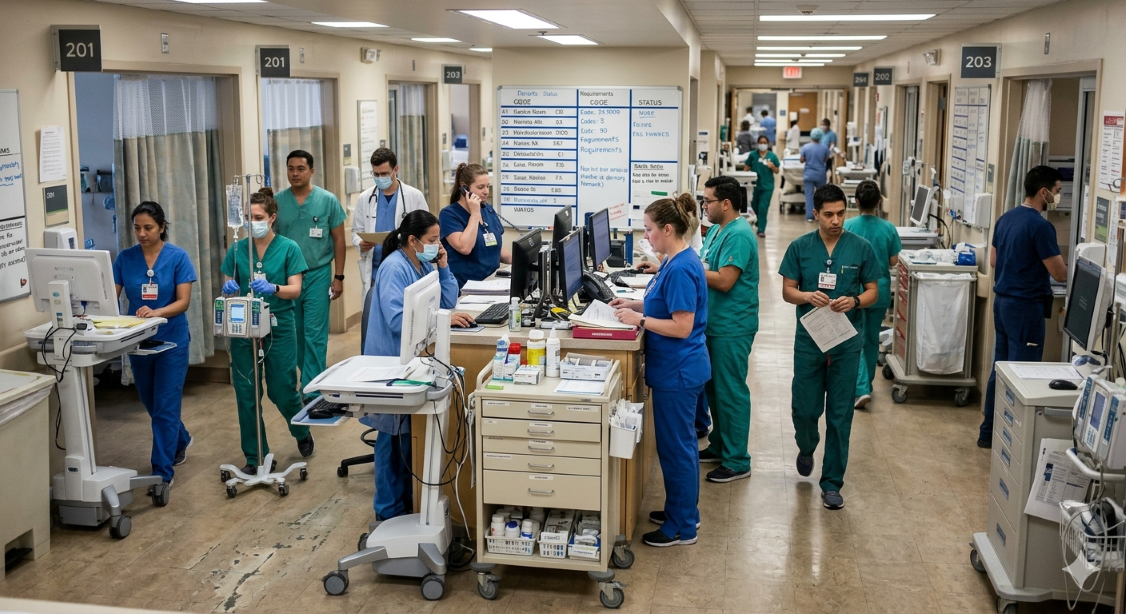
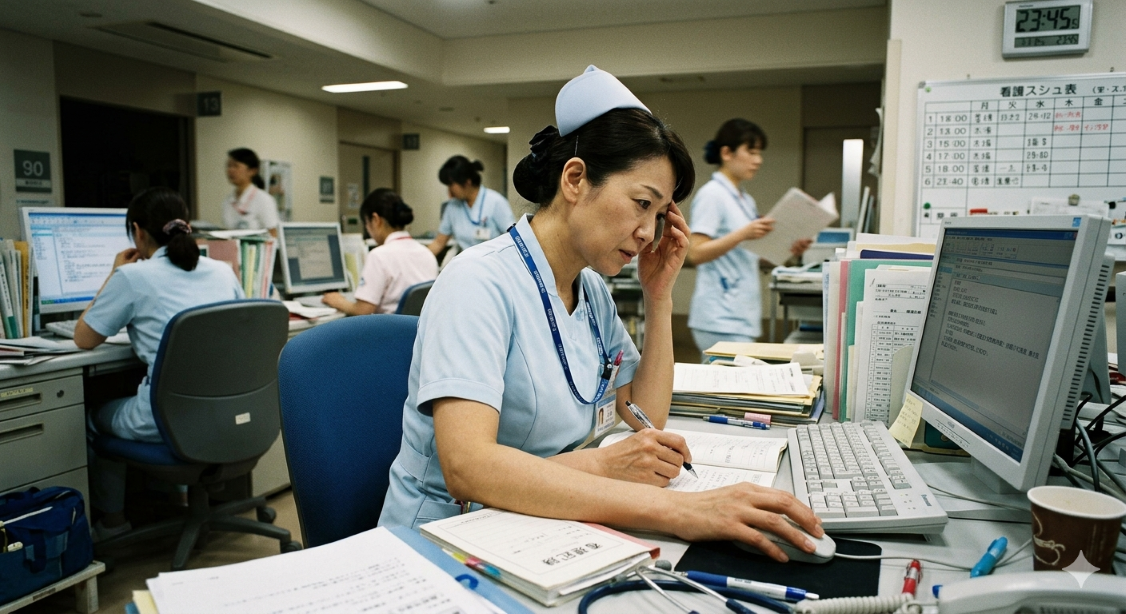

# 1.Library Installation

In [ ]:
!pip install -U transformers accelerate bitsandbytes

# 2.Model loading and inference exection

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "google/gemma-4-e2b-it"

# BitsAndBytes configuration for memory optimization (4-bit quantization)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model... Optimizing memory usage...")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
    torch_dtype=torch.bfloat16
)

def generate_nursing_assessment(patient_data, mode):
    """
    Function to generate nursing assessment (Optimized for Markdown output)
    """
    # Standard Markdown instructions for structured output
    markdown_format = (
       "\n\n### Output Style Instructions:\n"
        "1. Use Markdown format with clear headers (##), bold text (**), and bullet points.\n"
        "2. IMPORTANT: DO NOT use LaTeX or math symbols like '$' for numbers and units.\n"
        "3. Write temperatures as '38.5°C' and oxygen saturation as '92%' using standard text.\n"
        "4. Ensure all numerical data is easy to read for medical professionals."
        "5. Present Vital Signs in a Markdown Table for better visibility."
    
    )

    # System instructions based on the selected mode
    if mode == "SOAP Format":
        system_instructions = (
            "You are an expert nurse. Analyze the patient data and provide your response "
            "strictly in the SOAP format: S (Subjective), O (Objective), A (Assessment), and P (Plan)."
        )
    elif mode == "For Nursing Students":
        system_instructions = (
            "You are a nursing education expert. Based on the provided case, "
            "explain the key points students should focus on and the priority nursing diagnoses "
            "from an educational perspective."
        )
    else:
        system_instructions = (
            "You are an expert nurse. Based on the patient data, provide a professional "
            "Assessment (clinical reasoning) and key points for the future Nursing Care Plan."
        )

    # Assembling the final prompt
    prompt = f"{system_instructions}{markdown_format}\n\nPatient Data:\n{patient_data}"
    
    messages = [
        {"role": "user", "content": prompt},
    ]
    
    # Prepare inputs for the model
    inputs = tokenizer.apply_chat_template(
        messages, 
        return_tensors="pt", 
        add_generation_prompt=True,
        return_dict=True
    ).to(model.device)
    
    # Generate response
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024, 
            do_sample=True, 
            temperature=0.7,
            top_p=0.9
        )
    
    # Decode the result (excluding the input prompt)
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)

# **3.Screen launch using Gradio**

In [ ]:
!pip install gradio

# **4.Gradioによる画面起動**

In [ ]:
import gradio as gr

# UI Design with Soft Theme
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏥 Gemma 4: Nursing Assessment Support AI")
    gr.Markdown(
        "Enter patient data and click the button to generate a professional assessment in **Rich Text (Markdown)** format."
    )
    
    with gr.Row():
        # Left Column: Input
        with gr.Column(scale=1):
            input_text = gr.Textbox(
                label="Patient Data / Clinical Progress", 
                placeholder="e.g., 80s male, admitted for aspiration pneumonia. Fever of 38.5C since last night...",
                lines=10
            )
            mode = gr.Radio(
                choices=["Standard Assessment", "SOAP Format", "For Nursing Students"], 
                label="Output Mode", 
                value="Standard Assessment"
            )
            submit_btn = gr.Button("Generate Assessment", variant="primary")
        
        # Right Column: Output
        with gr.Column(scale=1):
            gr.Markdown("### 📋 AI Assessment Result")
            output_markdown = gr.Markdown(
                value="*The assessment results will appear here.*", 
                label="Analysis Result"
            )
            
    # Link button click to the generation function
    submit_btn.click(
        fn=generate_nursing_assessment, 
        inputs=[input_text, mode], 
        outputs=output_markdown
    )

# Launch the app with a public URL
demo.launch(share=True)